In [3]:

from langchain_groq import ChatGroq
from langgraph.graph import StateGraph ,START, END 
from typing import TypedDict 
from pydantic import BaseModel, Field
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
load_dotenv(override=True)
import os 
import time


In [4]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm_model=ChatGroq(model="llama-3.1-8b-instant")

In [5]:
#1, define the state

class CrashState(TypedDict):
    input:str
    step1:str
    step2:str
    step3:str

In [14]:
#2. define steps

def step_1(state:CrashState):
    #some code that might crash 
    print("✅ Step 1 executed.....")
    return {"step1":"Done", "input":state["input"]}

def step_2(state:CrashState):
    #some code that might crash 
    print("STep 2 .. hanging now, manually interrupt from notebook toolbar ( STOP button on top) to test the fault tolerance ")
    time.sleep(30)
    return {"step2":"Done"}

def step_3(state:CrashState):
    #some code that might crash 
    print("✅ Step 3 executed.....")
    return {"step3":"Done"}   

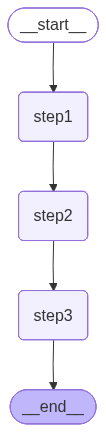

In [15]:
#Build the graph

graph = StateGraph(CrashState)
graph.add_node("step1", step_1)
graph.add_node("step2", step_2)
graph.add_node("step3", step_3)

graph.add_edge(START, "step1")
graph.add_edge("step1", "step2")
graph.add_edge("step2", "step3")
graph.add_edge("step3", END)

checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)
workflow

In [16]:
try:
    print("Running Graph  ... Please manually interrupt Step 2")
    workflow.invoke({"input":"start"},config={'configurable': {"thread_id":"thread_1"}})
except KeyboardInterrupt:
    print("Workflow interrupted, now re-running to test fault tolerance, it should resume from step 2")

Running Graph  ... Please manually interrupt Step 2
✅ Step 1 executed.....
STep 2 .. hanging now, manually interrupt from notebook toolbar ( STOP button on top) to test the fault tolerance 
Workflow interrupted, now re-running to test fault tolerance, it should resume from step 2


In [9]:
workflow.get_state({"configurable" : {"thread_id":"thread_1"}})

StateSnapshot(values={'input': 'start', 'step1': 'Done'}, next=('step2',), config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f16647f-ba46-6992-8001-7e026aa7689e'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-06-12T10:17:57.576297+00:00', parent_config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f16647f-ba3e-6d27-8000-45c4a725e114'}}, tasks=(PregelTask(id='097a2f11-b447-a3b2-b39b-6099dd2ca4f0', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [10]:
list(workflow.get_state({"configurable" : {"thread_id":"thread_1"}}))

[{'input': 'start', 'step1': 'Done'},
 ('step2',),
 {'configurable': {'thread_id': 'thread_1',
   'checkpoint_ns': '',
   'checkpoint_id': '1f16647f-ba46-6992-8001-7e026aa7689e'}},
 {'source': 'loop', 'step': 1, 'parents': {}},
 '2026-06-12T10:17:57.576297+00:00',
 {'configurable': {'thread_id': 'thread_1',
   'checkpoint_ns': '',
   'checkpoint_id': '1f16647f-ba3e-6d27-8000-45c4a725e114'}},
 (PregelTask(id='097a2f11-b447-a3b2-b39b-6099dd2ca4f0', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),),
 ()]

In [17]:
#Rerun the workflow to see if it resumes from step 2
final_state = workflow.invoke(None,config={'configurable': {"thread_id":"thread_1"}})
print("\n Final state:" ,final_state)

STep 2 .. hanging now, manually interrupt from notebook toolbar ( STOP button on top) to test the fault tolerance 
✅ Step 3 executed.....

 Final state: {'input': 'start', 'step1': 'Done', 'step2': 'Done', 'step3': 'Done'}


In [18]:
workflow.get_state({"configurable" : {"thread_id":"thread_1"}})

StateSnapshot(values={'input': 'start', 'step1': 'Done', 'step2': 'Done', 'step3': 'Done'}, next=(), config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f16648f-8ba5-6ea1-8003-96458be01a37'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-06-12T10:25:02.183761+00:00', parent_config={'configurable': {'thread_id': 'thread_1', 'checkpoint_ns': '', 'checkpoint_id': '1f16648f-8b9f-67fa-8002-277e6c652464'}}, tasks=(), interrupts=())